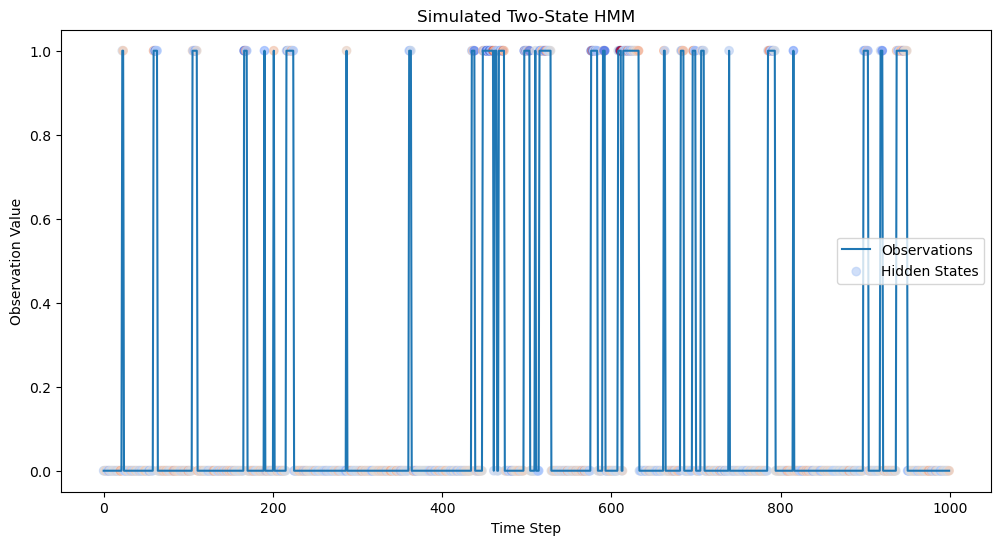

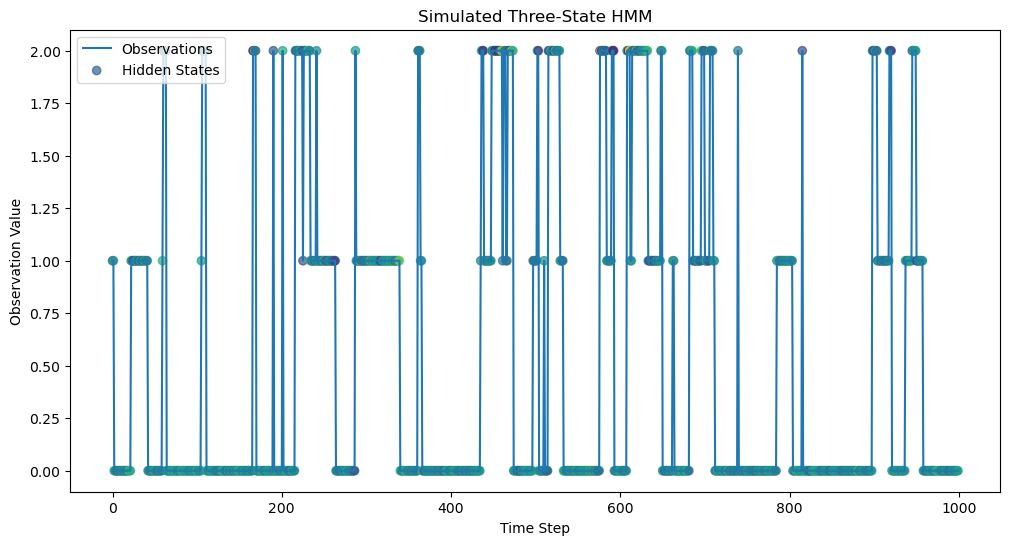

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

def simulate_hmm(n_samples, mu, sigma, transition_matrix, start_prob=None, seed=None):
    """
    Simulates data from a Gaussian Hidden Markov Model (HMM).
    
    Args:
        n_samples (int): Number of observations to generate.
        mu (list): Means of the Gaussian emissions for each state.
        sigma (list): Standard deviations of the Gaussian emissions for each state.
        transition_matrix (ndarray): Transition probability matrix.
        start_prob (list): Initial state probabilities (optional).
        seed (int): Random seed for reproducibility (optional).
    
    Returns:
        states (ndarray): The hidden states sequence.
        observations (ndarray): The generated observations.
    """
    np.random.seed(seed)
    
    n_states = len(mu)
    if start_prob is None:
        start_prob = np.ones(n_states) / n_states  # Uniform initial state probabilities if not provided

    # Define HMM
    model = GaussianHMM(n_components=n_states, covariance_type="diag", init_params="")
    model.startprob_ = start_prob
    model.transmat_ = transition_matrix
    model.means_ = np.array(mu).reshape(-1, 1)
    model.covars_ = np.array(sigma).reshape(-1, 1) ** 2

    # Sample from HMM
    states, observations = model.sample(n_samples)

    return states, observations


# Two-State HMM Parameters
mu_2state = [0.0123, -0.0157]
sigma_2state = [0.0347, 0.0778]
transition_2state = np.array([[0.9629, 0.0371], [0.2101, 0.7899]])

# Simulate two-state HMM
n_samples = 1000
states_2state, observations_2state = simulate_hmm(n_samples, mu_2state, sigma_2state, transition_2state, seed=42)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(observations_2state, label="Observations")
plt.scatter(range(n_samples), observations_2state, c=states_2state, cmap="coolwarm", label="Hidden States", alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Observation Value")
plt.title("Simulated Two-State HMM")
plt.legend()
plt.show()


# Three-State HMM Parameters
mu_3state = [0.0123, 0.0000, -0.0157]
sigma_3state = [0.0347, 0.0500, 0.0778]
transition_3state = np.array([
    [0.9629, 0.0185, 0.0186],
    [0.0618, 0.8764, 0.0618],
    [0.1051, 0.1050, 0.7899]
])

# Simulate three-state HMM
states_3state, observations_3state = simulate_hmm(n_samples, mu_3state, sigma_3state, transition_3state, seed=42)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(observations_3state, label="Observations")
plt.scatter(range(n_samples), observations_3state, c=states_3state, cmap="viridis", label="Hidden States", alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Observation Value")
plt.title("Simulated Three-State HMM")
plt.legend()
plt.show()


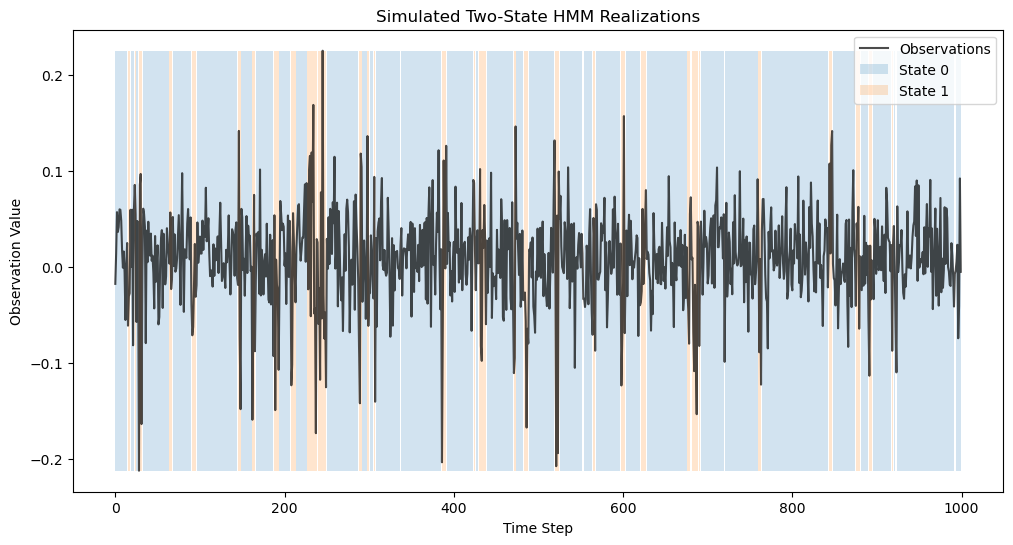

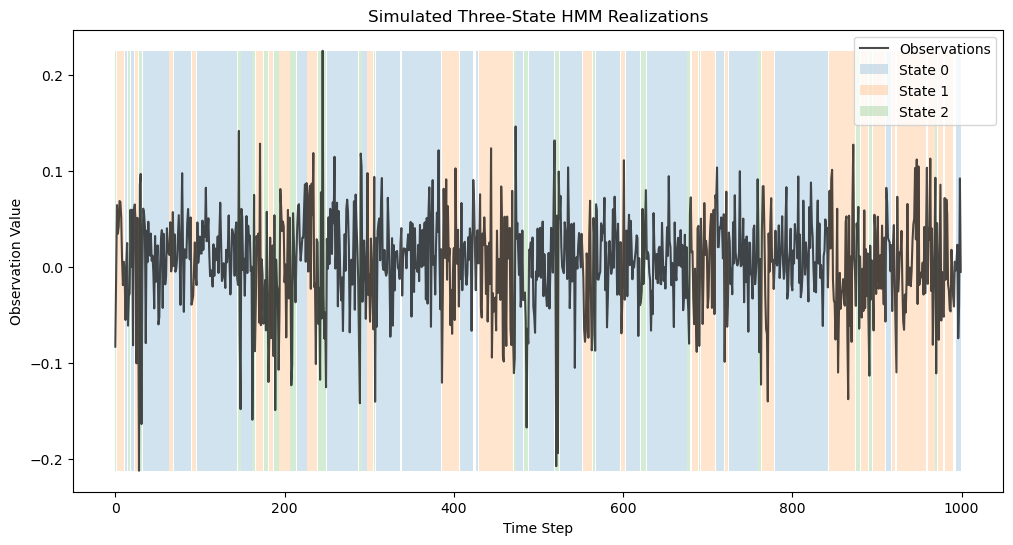

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_markov_chain(n_samples, transition_matrix, seed=None):
    """
    Simulates a discrete Markov chain given a transition matrix.
    
    Args:
        n_samples (int): Number of time steps.
        transition_matrix (ndarray): State transition matrix.
        seed (int, optional): Random seed for reproducibility.
    
    Returns:
        states (ndarray): Sequence of hidden states.
    """
    np.random.seed(seed)
    n_states = transition_matrix.shape[0]
    states = np.zeros(n_samples, dtype=int)

    # Start at a random state
    states[0] = np.random.choice(n_states)

    for t in range(1, n_samples):
        states[t] = np.random.choice(n_states, p=transition_matrix[states[t-1]])

    return states

def generate_observations(states, mu, sigma):
    """
    Generates Gaussian observations based on the hidden states.

    Args:
        states (ndarray): Sequence of hidden states.
        mu (list): List of means for each state.
        sigma (list): List of standard deviations for each state.

    Returns:
        observations (ndarray): Generated observations.
    """
    observations = np.array([np.random.normal(mu[s], sigma[s]) for s in states])
    return observations

def plot_simulation(states, observations, title):
    """
    Plots the simulated observations along with the hidden states.
    
    Args:
        states (ndarray): Sequence of hidden states.
        observations (ndarray): Generated observations.
        title (str): Title of the plot.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot observations
    plt.plot(observations, label="Observations", color="black", alpha=0.7)

    # Overlay hidden states as background colors
    for state in np.unique(states):
        plt.fill_between(range(len(states)), min(observations), max(observations),
                         where=(states == state), alpha=0.2, label=f"State {state}")

    plt.xlabel("Time Step")
    plt.ylabel("Observation Value")
    plt.title(title)
    plt.legend()
    plt.show()

# Number of samples
n_samples = 1000

# ----------- TWO-STATE HMM SIMULATION -----------
mu_2state = [0.0123, -0.0157]
sigma_2state = [0.0347, 0.0778]
transition_2state = np.array([[0.9629, 0.0371], [0.2101, 0.7899]])

# Simulate hidden states and observations
states_2state = simulate_markov_chain(n_samples, transition_2state, seed=42)
observations_2state = generate_observations(states_2state, mu_2state, sigma_2state)

# Plot results
plot_simulation(states_2state, observations_2state, "Simulated Two-State HMM Realizations")


# ----------- THREE-STATE HMM SIMULATION -----------
mu_3state = [0.0123, 0.0000, -0.0157]
sigma_3state = [0.0347, 0.0500, 0.0778]
transition_3state = np.array([
    [0.9629, 0.0185, 0.0186],
    [0.0618, 0.8764, 0.0618],
    [0.1051, 0.1050, 0.7899]
])

# Simulate hidden states and observations
states_3state = simulate_markov_chain(n_samples, transition_3state, seed=42)
observations_3state = generate_observations(states_3state, mu_3state, sigma_3state)

# Plot results
plot_simulation(states_3state, observations_3state, "Simulated Three-State HMM Realizations")


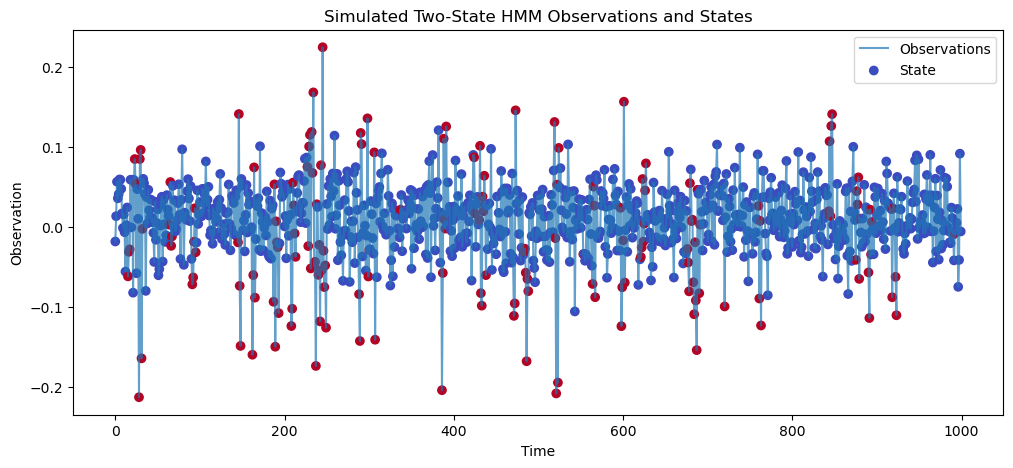

In [ ]:
import numpy as np

def simulate_hmm(n_samples, mu, sigma, transition_matrix, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    # Initialize state sequence
    states = np.zeros(n_samples, dtype=int)
    observations = np.zeros(n_samples)
    
    # Initial state
    states[0] = np.random.choice([0, 1])  # Assuming equal probability for start
    
    for t in range(1, n_samples):
        # Transition to next state
        states[t] = np.random.choice([0, 1], p=transition_matrix[states[t - 1]])
    
    # Generate observations based on state
    for t in range(n_samples):
        observations[t] = np.random.normal(mu[states[t]], sigma[states[t]])
    
    return states, observations

# Define Two-State HMM Parameters
mu_2state = [0.0123, -0.0157]
sigma_2state = [0.0347, 0.0778]
transition_2state = np.array([[0.9629, 0.0371], [0.2101, 0.7899]])

# Simulate two-state HMM
n_samples = 1000
states_2state, observations_2state = simulate_hmm(n_samples, mu_2state, sigma_2state, transition_2state, seed=42)

# Display first few samples
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(observations_2state, label="Observations", linestyle='-', alpha=0.7)
plt.scatter(range(n_samples), observations_2state, c=states_2state, cmap="coolwarm", marker="o", label="State")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.legend()
plt.title("Simulated Two-State HMM Observations and States")
plt.show()


In [7]:
observations_2state.shape

(1000,)